## Código de imposición de condiciones periódicas

El siguiente *notebook* presenta un código para la reducción del sistema inicial de la celda unitaria al imponer condiciones de periodicidad. Como referencia de la asociación de grados de libertad entre nodos se presenta la siguiente imagen:

<img src="./img/periodicConditionsFEM.png" width=640 align="middle">


<div class="alert alert-block alert-warning">
<b> Nota importante:</b> El código es adaptado a partir de las funciones adicionales para análisis de Bloch de la documentación de SolidSpy <a href="https://github.com/AppliedMechanics-EAFIT/SolidsPy/blob/master/solidspy/blochutil.py">que se encuentra aquí.</a>
</div>

### Funciones:

In [1]:
"""
Periodic Boundary Conditions utilities
------------------------

"""
import numpy as np
from scipy.sparse import coo_matrix

#%% Auxiliar
def reassign_dof_periodicBC(ndofs, dofs_ima, dofs_ref):
    """Find dof number after applying boundary conditions

    Parameters
    ----------
    ndofs : int
        Number of degrees of freedom.
    dofs_ima : list, int
        List with image degrees of freedom.
    dofs_ref : list, int
        List with reference degrees of freedom.


    Examples
    --------
    
    Let us consider an example for  a square made with spring and masses.
    In that case we have the following dofs mappings.
    
    >>> dofs_ref = [0, 1, 0, 1, 0, 1]
    >>> dofs_ima = [2, 3, 4, 5, 6, 7]
    
    And the new numbering would be
    
    >>> new_num = reassign_dof_periodicBC(8, dofs_ima, dofs_ref)
    >>> new_num
    [0, 1, 0, 1, 0, 1, 0, 1]

    Returns
    -------
    new_num : list, int
        List with new numbering for the dof after applying Bloch analysis.

    """
    new_num = []
    cont = 0
    for cont_dof in range(ndofs):
        if cont_dof in dofs_ima:
            cont += 1
            ref_dof = dofs_ref[dofs_ima.index(cont_dof)]
            if ref_dof < cont_dof:
                new_num.append(ref_dof)
            else:
                new_num.append(ref_dof - cont)
        else:
            new_num.append(cont_dof - cont)
    return new_num


#%% Sparse matrices
def periodicBC_transform_mat(def_const, ndofs, nodes_ref, nodes_ima,
                             dofs_ref, dofs_ima, nodes_ref_dof, nodes_ima_dof,
                             new_num,
                             nodes=None,
                             mode="tension_x",
                             disp_value=0.64):
    """
    Form transformation matrices for Periodic Boundary Conditions
    with imposed macro-deformations (tension_x, tension_y, shear).

    Parameters
    ----------
    def_const : float
        Default deformation constant for periodic relation.
    ndofs : int
        Total number of degrees of freedom.
    nodes_ref, nodes_ima : list[int]
        Reference and image nodes for periodic BC.
    dofs_ref, dofs_ima : list[int]
        DOFs corresponding to nodes_ref and nodes_ima.
    nodes_ref_dof, nodes_ima_dof : dict
        Dicts mapping node -> [ux_dof, uy_dof].
    new_num : list[int]
        New numbering after periodic renumbering.
    nodes : ndarray, optional
        Full node array (required to detect top/right faces).
        Assumed columns: [id, x, y].
    mode : str
        Type of macroscopic deformation.
        Options: 'tension_x', 'tension_y', 'shear'.
    disp_value : float
        Prescribed displacement magnitude.

    Returns
    -------
    Tmat : scipy.sparse.csr_matrix
        Transformation matrix.
    g_vec : ndarray
        Vector of prescribed displacements (periodic + imposed macro load).
    """

    rows, cols, vals = [], [], []
    g_vec = np.zeros(ndofs)

    # --- Inner nodes (no periodic relation) ---
    for cont_dof in range(ndofs):
        if cont_dof not in dofs_ima:
            rows.append(cont_dof)
            cols.append(new_num[cont_dof])
            vals.append(1)

    # --- Apply periodic BC relations + imposed macro displacement ---
    for node_ima, node_ref in zip(nodes_ima, nodes_ref):
        dof_ref = nodes_ref_dof[node_ref]
        dof_ima = nodes_ima_dof[node_ima]
        for cont_ref, cont_ima in zip(dof_ref, dof_ima):
            rows.append(cont_ima)
            cols.append(new_num[cont_ref])
            vals.append(1)
            g_vec[cont_ima] = def_const  # base periodic link

    # --- Apply macroscopic deformation ---
    if nodes is not None:
        x_max, x_min = np.max(nodes[:, 1]), np.min(nodes[:, 1])
        y_max, y_min = np.max(nodes[:, 2]), np.min(nodes[:, 2])

        for node in nodes_ima:
            dofs = nodes_ima_dof[node]
            ux, uy = dofs[0], dofs[1]
            x, y = nodes[node, 1], nodes[node, 2]

            # --- CASE 1: Tensión en X ---
            if mode == "tension_x" and np.isclose(x, x_max):
                g_vec[ux] += disp_value

            # --- CASE 2: Tensión en Y ---
            elif mode == "tension_y" and np.isclose(y, y_max):
                g_vec[uy] += disp_value

            # --- CASE 3: Corte puro (shear) ---
            elif mode == "shear":
                if np.isclose(y, y_max):   # cara superior
                    g_vec[ux] = disp_value
                elif np.isclose(y, y_min): # cara inferior
                    g_vec[ux] = 0.0

    nconds = len(dofs_ref)
    Tmat = coo_matrix((vals, (rows, cols)), shape=(ndofs, ndofs - nconds)).tocsr()
    return Tmat, g_vec


#%% Doctests
if __name__ == "__main__":    
    import doctest
    doctest.testmod()

#### Identificiación de nodos

In [2]:
def periodicBC_nodes_identification(nodes):

    # Identificar id de los nodos referencia de la izquierda
    nodes_mask_id_L = (nodes[:,1] == np.min(nodes[:,1]))
    ref_nodes_L = nodes[:,0][nodes_mask_id_L]
    ref_nodes_L = np.delete(ref_nodes_L, -1)
    
    # Identificar id de los nodos imagen de la derecha
    nodes_mask_id_R = (nodes[:,1] == np.max(nodes[:,1]))
    ref_nodes_R = nodes[:,0][nodes_mask_id_R]
    ref_nodes_R= np.delete(ref_nodes_R, -1)
    
    # Identificar id de los nodos referencia de abajo
    nodes_mask_id_B = (nodes[:,2] == np.min(nodes[:,2]))
    ref_nodes_B = nodes[:,0][nodes_mask_id_B]
    ref_nodes_B = np.delete(ref_nodes_B, -1)
    
    # Identificar id de los nodos imagen de arriba
    nodes_mask_id_T = (nodes[:,2] == np.max(nodes[:,2]))
    ref_nodes_T = nodes[:,0][nodes_mask_id_T]
    ref_nodes_T = np.delete(ref_nodes_T, -1)
    
    # Identificar id del nodo referencia BL
    nodes_mask_id_BL = nodes[nodes_mask_id_L][:,2] == np.min(nodes[nodes_mask_id_L][:,2])
    ref_nodes_BL = nodes[:,0][nodes_mask_id_L][nodes_mask_id_BL]
    
    # Identificar id del nodo imagen TR
    nodes_mask_id_TR = nodes[nodes_mask_id_R][:,2] == np.max(nodes[nodes_mask_id_R][:,2])
    ref_nodes_TR = nodes[:,0][nodes_mask_id_R][nodes_mask_id_TR]

    nodes_ref =  np.int_(np.concatenate((ref_nodes_L, ref_nodes_B, ref_nodes_BL)))
    nodes_ima = np.int_(np.concatenate((ref_nodes_R, ref_nodes_T, ref_nodes_TR)))
    
    return nodes_ref, nodes_ima

#### Generar diccionario nodos-DOFs y lista de DOFs

In [3]:
def periodicBC_generate_inputs(nodes_id_list):
    node_dofs_dict = {}
    dofs_list = []
    for node in nodes_id_list:
        dofs = [2 * node, 2 * node + 1]
        
        dofs_list.extend(dofs)
        node_dofs_dict[node] = dofs
        
    return dofs_list, node_dofs_dict

---

### Aplicación FEM

In [4]:
import solidspy.assemutil as ass
import solidspy.solutil as sol
import solidspy.postprocesor as pos
from datetime import datetime

---

#### Obtener la matriz de rigidez $K_{global}$

In [5]:
# Pre-Procesamiento
file_path = "./fem/"
nodes = np.loadtxt(file_path + 'nodes.txt', ndmin=2)
mats = np.loadtxt(file_path + 'mater.txt', ndmin=2)
elements = np.loadtxt(file_path + 'eles.txt', ndmin=2, dtype=int)

start_time = datetime.now()

assem_op, bc_array, neq = ass.DME(nodes[:, -2:], elements)

print("Number of nodes: {}".format(nodes.shape[0]))
print("Number of elements: {}".format(elements.shape[0]))
print("Number of equations: {}".format(neq))

# Ensamblaje del sistema
stiff_mat, _ = ass.assembler(elements, mats, nodes[:, :3], neq, assem_op)

Number of nodes: 4225
Number of elements: 4096
Number of equations: 8450


In [130]:
stiff_mat

<8450x8450 sparse matrix of type '<class 'numpy.float64'>'
	with 148996 stored elements in Compressed Sparse Row format>

#### Obtener la matriz de transformación, $[T]$ , y el "constraint gap vector", $\{g \}$.

In [131]:
nodes

array([[0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [1.00000e+00, 1.56250e-02, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [2.00000e+00, 3.12500e-02, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       ...,
       [4.22200e+03, 9.68750e-01, 1.00000e+00, 0.00000e+00, 0.00000e+00],
       [4.22300e+03, 9.84375e-01, 1.00000e+00, 0.00000e+00, 0.00000e+00],
       [4.22400e+03, 1.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00]])

In [132]:
ndofs = 2*len(nodes)
nodes_ref, nodes_ima = periodicBC_nodes_identification(nodes)
dofs_ref, nodes_ref_dof = periodicBC_generate_inputs(nodes_ref)
dofs_ima, nodes_ima_dof = periodicBC_generate_inputs(nodes_ima)
new_num = reassign_dof_periodicBC(ndofs, dofs_ima, dofs_ref)

In [133]:
disp_constant = 1
t_mat_tx, g_vec_tx = periodicBC_transform_mat(disp_constant, ndofs, nodes_ref, nodes_ima,
                        dofs_ref, dofs_ima, nodes_ref_dof, nodes_ima_dof,
                        new_num,nodes=nodes,mode="tension_x")

In [134]:
t_mat_tx.toarray()

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]], dtype=int32)

In [135]:
g_vec_tx.shape

(8450,)

In [136]:
t_mat_tx.shape

(8450, 8192)

In [137]:
stiff_mat

<8450x8450 sparse matrix of type '<class 'numpy.float64'>'
	with 148996 stored elements in Compressed Sparse Row format>

#### Solución del sistema (Tension en x)

In [138]:
stiff_mat_hat_tx = t_mat_tx.T @ stiff_mat @ t_mat_tx
rhs_hat_tx = t_mat_tx.T @ -stiff_mat @ g_vec_tx

disp_hat_tx = sol.static_sol(stiff_mat_hat_tx.tocsr(), rhs_hat_tx)

disp_tx = t_mat_tx @ disp_hat_tx + g_vec_tx

end_time = datetime.now()
print('Duration for system solution: {}'.format(end_time - start_time))

Duration for system solution: 0:00:04.541162


C:\Users\juanm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\solidspy\postprocesor.py:107: UserWarning: The following kwargs were not used by contour: 'shading'
  disp_plot(tri, field, levels, shading="gouraud")


Duration for post processing: 0:00:02.979158
Analysis terminated successfully!


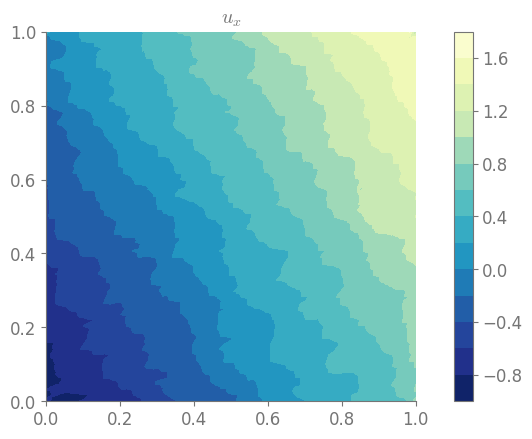

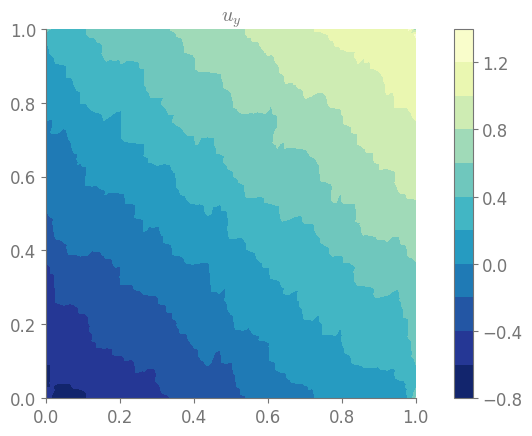

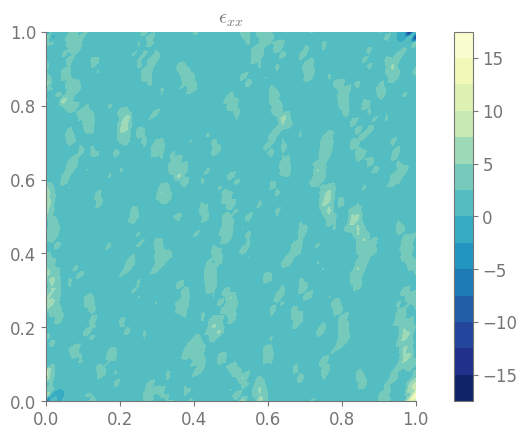

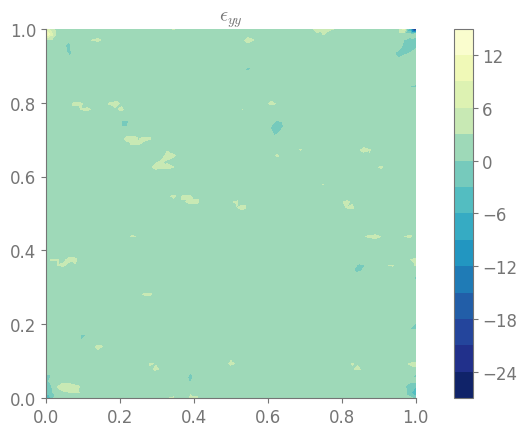

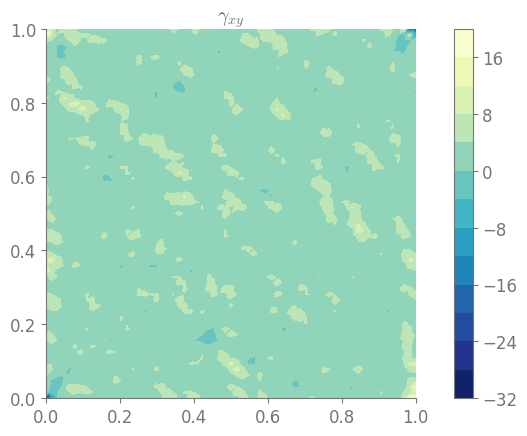

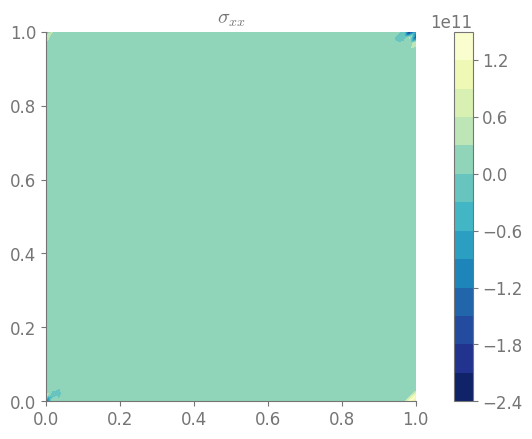

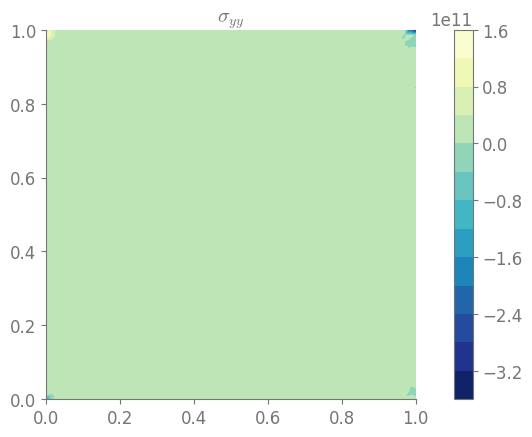

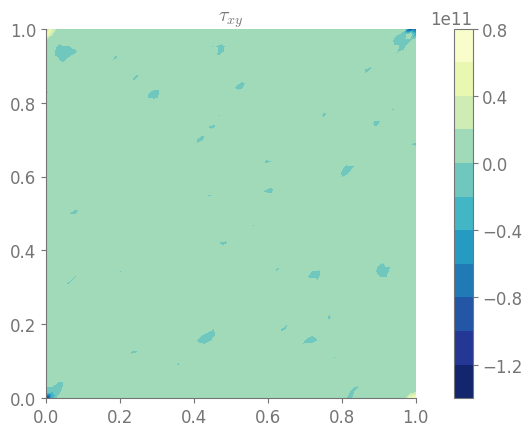

In [139]:
# Post-processing
start_time = datetime.now()
disp_complete_tx = pos.complete_disp(bc_array, nodes, disp_tx)
strain_nodes_tx, stress_nodes_tx = pos.strain_nodes(nodes, elements, mats,
                                            disp_complete_tx)
pos.fields_plot(elements, nodes, disp_complete_tx, E_nodes=strain_nodes_tx,
                S_nodes=stress_nodes_tx)
end_time = datetime.now()
print('Duration for post processing: {}'.format(end_time - start_time))
print('Analysis terminated successfully!')

#### Solución del sistema (Tension en y)

In [140]:
t_mat_ty, g_vec_ty = periodicBC_transform_mat(disp_constant, ndofs, nodes_ref, nodes_ima,
                        dofs_ref, dofs_ima, nodes_ref_dof, nodes_ima_dof,
                        new_num,nodes=nodes,mode="tension_y")
stiff_mat_hat_ty = t_mat_ty.T @ stiff_mat @ t_mat_ty
rhs_hat_ty = t_mat_ty.T @ -stiff_mat @ g_vec_ty

disp_hat_ty = sol.static_sol(stiff_mat_hat_ty.tocsr(), rhs_hat_ty)

disp_ty = t_mat_ty @ disp_hat_ty + g_vec_ty

end_time = datetime.now()
print('Duration for system solution: {}'.format(end_time - start_time))

Duration for system solution: 0:00:05.439460


Duration for post processing: 0:00:03.263380
Analysis terminated successfully!


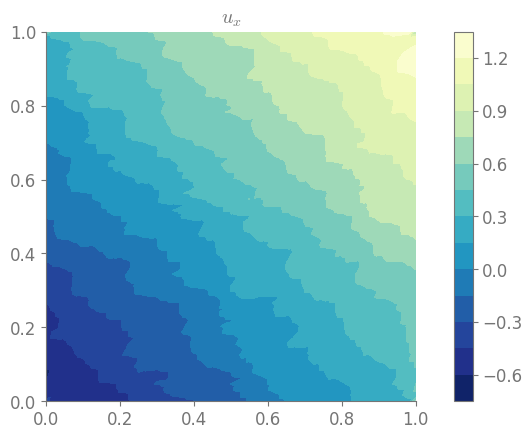

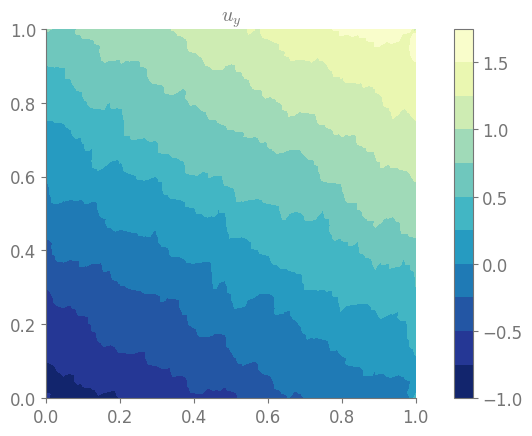

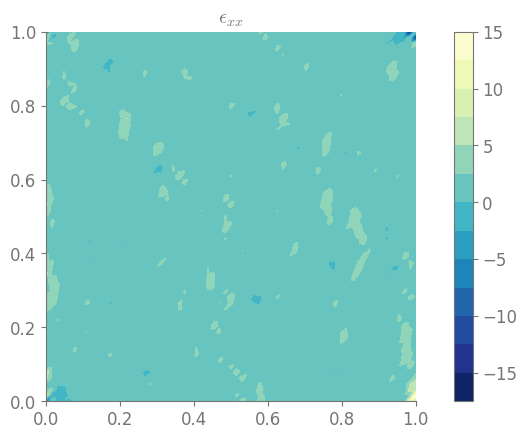

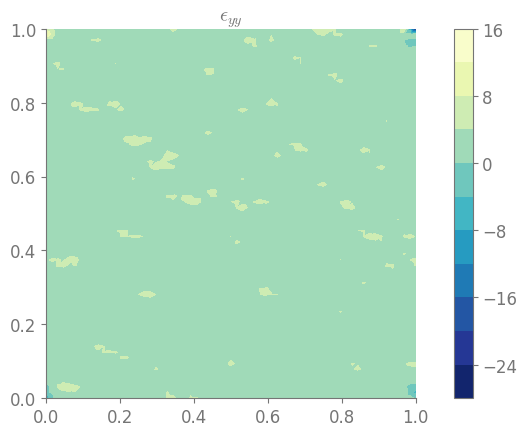

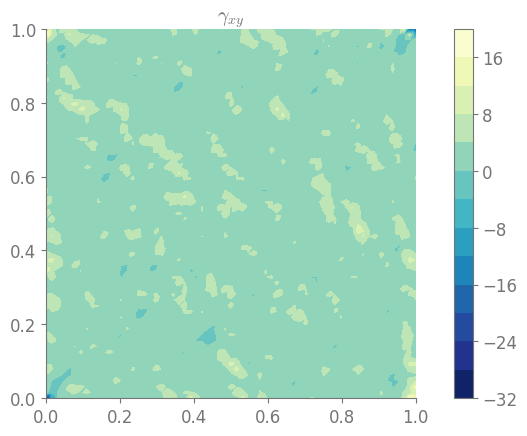

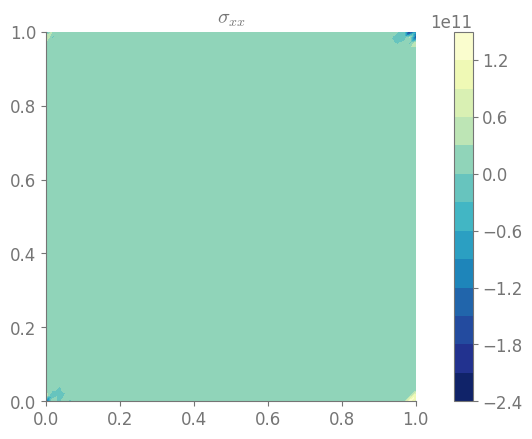

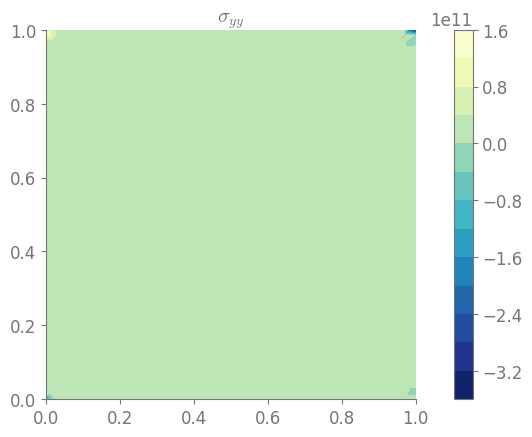

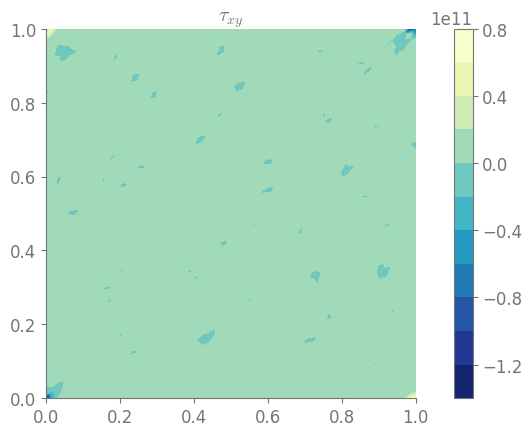

In [141]:
start_time = datetime.now()
disp_complete_ty = pos.complete_disp(bc_array, nodes, disp_ty)
strain_nodes_ty, stress_nodes_ty = pos.strain_nodes(nodes, elements, mats,
                                            disp_complete_ty)
pos.fields_plot(elements, nodes, disp_complete_ty, E_nodes=strain_nodes_ty,
                S_nodes=stress_nodes_ty)
end_time = datetime.now()
print('Duration for post processing: {}'.format(end_time - start_time))
print('Analysis terminated successfully!')

#### Solución del sistema (Corte)

In [142]:
t_mat_sh, g_vec_sh = periodicBC_transform_mat(disp_constant, ndofs, nodes_ref, nodes_ima,
                        dofs_ref, dofs_ima, nodes_ref_dof, nodes_ima_dof,
                        new_num,nodes=nodes,mode="shear")
stiff_mat_hat_sh = t_mat_sh.T @ stiff_mat @ t_mat_sh
rhs_hat_sh = t_mat_sh.T @ -stiff_mat @ g_vec_sh

disp_hat_sh = sol.static_sol(stiff_mat_hat_sh.tocsr(), rhs_hat_sh)

disp_sh = t_mat_sh @ disp_hat_sh + g_vec_sh

end_time = datetime.now()
print('Duration for system solution: {}'.format(end_time - start_time))

Duration for system solution: 0:00:05.749163


Duration for post processing: 0:00:03.252033
Analysis terminated successfully!


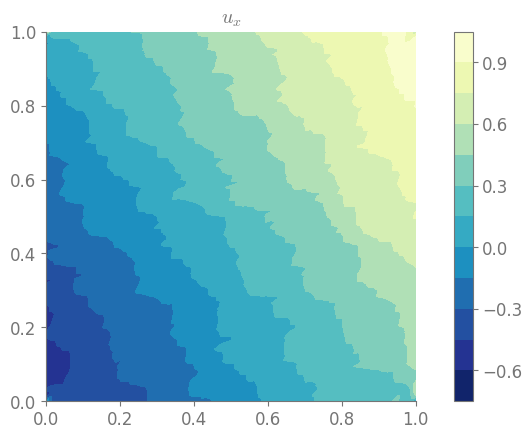

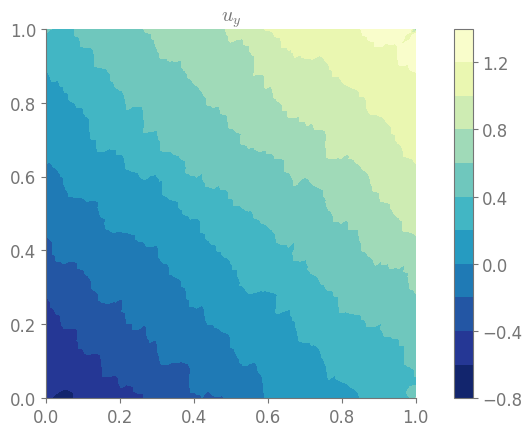

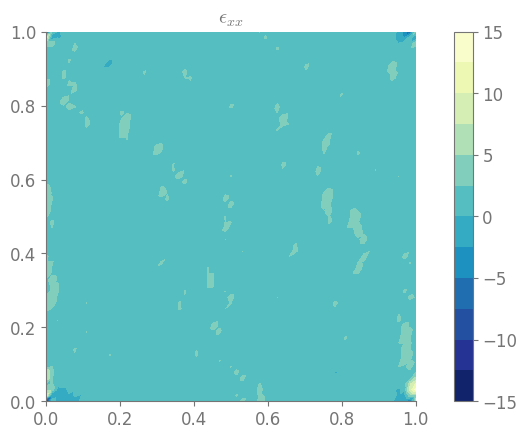

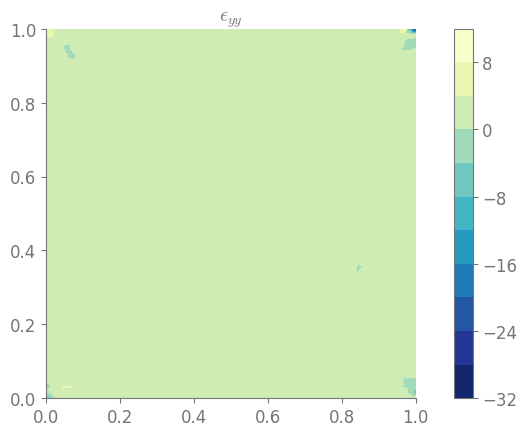

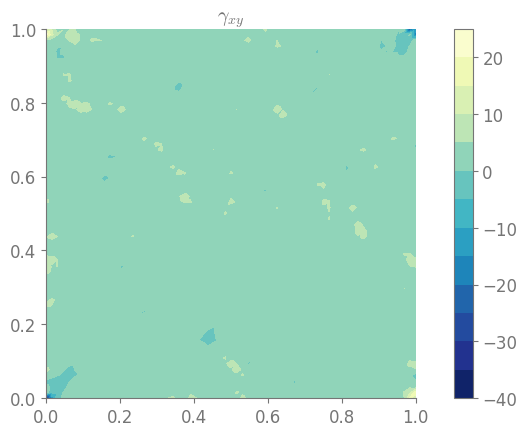

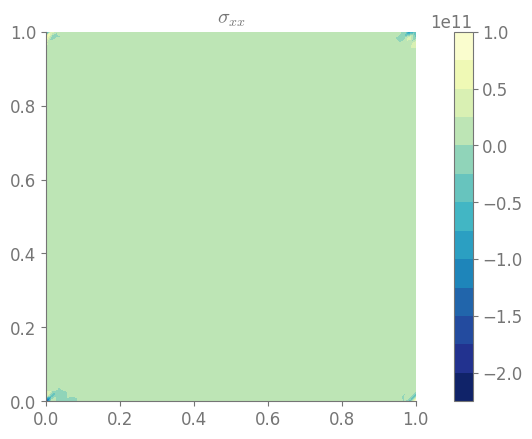

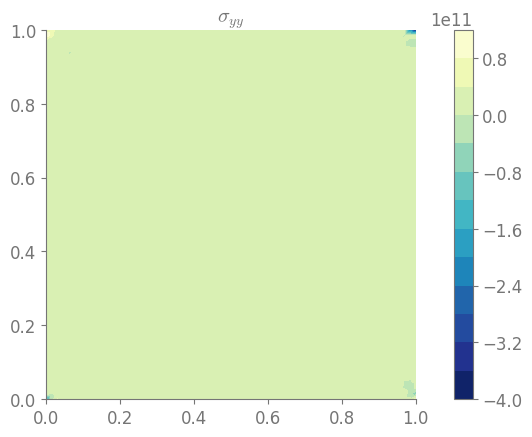

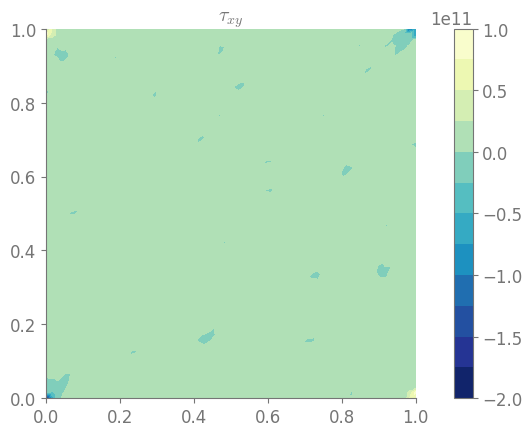

In [143]:
start_time = datetime.now()
disp_complete_sh = pos.complete_disp(bc_array, nodes, disp_sh)
strain_nodes_sh, stress_nodes_sh = pos.strain_nodes(nodes, elements, mats,
                                            disp_complete_sh)
pos.fields_plot(elements, nodes, disp_complete_sh, E_nodes=strain_nodes_sh,
                S_nodes=stress_nodes_sh)
end_time = datetime.now()
print('Duration for post processing: {}'.format(end_time - start_time))
print('Analysis terminated successfully!')

### Calculo de la matriz de coeficientes

In [144]:
strain = np.concatenate(
    [strain_nodes_tx.T, strain_nodes_ty.T, strain_nodes_sh.T],
    axis=1)
stress = np.concatenate(
    [stress_nodes_tx.T, stress_nodes_ty.T, stress_nodes_sh.T],
    axis=1)
strain[2,:] *= 0.5
C = (stress @ strain.T) @ np.linalg.inv(strain @ strain.T) / len(nodes)
C = 0.5*(C + C.T)
C

array([[773441.62489423, 120523.52393759, -44597.23758428],
       [120523.52393759, 912817.88389113, -35214.18646747],
       [-44597.23758428, -35214.18646747, 824342.84599915]])

In [145]:
strain.shape

(3, 12675)

In [146]:
val,vec = np.linalg.eig(C)
val

array([998490.76877486, 700043.43221872, 812068.15379094])

In [147]:
vec

array([[ 0.49585579,  0.86831205, -0.01269742],
       [ 0.81772148, -0.46194377,  0.34342326],
       [-0.29233306,  0.18067136,  0.93909491]])

In [ ]:
data = [C, C[1,:]]

: 